## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

import neuro_fuzzy_toolbox as nft

## Data

In [2]:
x_train = 2 * torch.rand(200, 2) - 1
x_train

tensor([[-0.3459, -0.8623],
        [-0.8319,  0.6266],
        [-0.1598, -0.3848],
        [ 0.7234, -0.0204],
        [ 0.8204, -0.6017],
        [ 0.1216, -0.9773],
        [-0.1675, -0.6839],
        [-0.3911, -0.2363],
        [-0.4543, -0.4032],
        [-0.0618,  0.8700],
        [ 0.5310, -0.3740],
        [ 0.9064, -0.0846],
        [ 0.1315, -0.8059],
        [-0.5747,  0.9369],
        [ 0.5686, -0.0966],
        [-0.3108,  0.9687],
        [-0.1724,  0.4928],
        [ 0.1946, -0.9053],
        [ 0.0637,  0.4029],
        [ 0.9923,  0.6430],
        [ 0.6946, -0.8442],
        [ 0.0125, -0.7107],
        [ 0.9954,  0.1049],
        [ 0.6493, -0.3769],
        [-0.8149,  0.2064],
        [ 0.1061,  0.5352],
        [-0.1672, -0.1828],
        [ 0.1969,  0.6273],
        [ 0.3337, -0.7218],
        [-0.4999, -0.8456],
        [ 0.1848,  0.4454],
        [ 0.4925, -0.4257],
        [ 0.4965,  0.7159],
        [ 0.9368, -0.3145],
        [-0.6855,  0.1331],
        [-0.9366,  0

In [3]:
y_train = torch.rand(200)
y_train

tensor([0.8315, 0.9100, 0.3420, 0.9438, 0.2197, 0.2992, 0.8944, 0.3865, 0.8401,
        0.3319, 0.1294, 0.0095, 0.3543, 0.5593, 0.8304, 0.9296, 0.8018, 0.9406,
        0.0415, 0.3911, 0.5817, 0.6967, 0.4990, 0.8451, 0.6395, 0.6964, 0.0561,
        0.6121, 0.5875, 0.8822, 0.3899, 0.1351, 0.6187, 0.5500, 0.9005, 0.8902,
        0.3938, 0.2946, 0.1662, 0.5638, 0.3881, 0.5650, 0.6895, 0.8601, 0.8294,
        0.2503, 0.9928, 0.3367, 0.2405, 0.2578, 0.2845, 0.2218, 0.5053, 0.9249,
        0.0189, 0.1068, 0.4502, 0.3719, 0.5989, 0.2854, 0.8045, 0.6214, 0.9025,
        0.6653, 0.9518, 0.1896, 0.2628, 0.5842, 0.6134, 0.5744, 0.7585, 0.4344,
        0.0216, 0.2407, 0.8958, 0.1140, 0.2115, 0.2857, 0.0552, 0.6801, 0.4611,
        0.0510, 0.4249, 0.6418, 0.3160, 0.6444, 0.7012, 0.6502, 0.1367, 0.7567,
        0.4415, 0.6475, 0.7761, 0.2649, 0.9302, 0.0454, 0.8518, 0.5565, 0.0534,
        0.0038, 0.9708, 0.1582, 0.8161, 0.1700, 0.9573, 0.8068, 0.0480, 0.0826,
        0.8344, 0.3406, 0.9335, 0.0806, 

## Model

In [4]:
model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=8, # 8 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.GeneralizedBell_MF(), # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

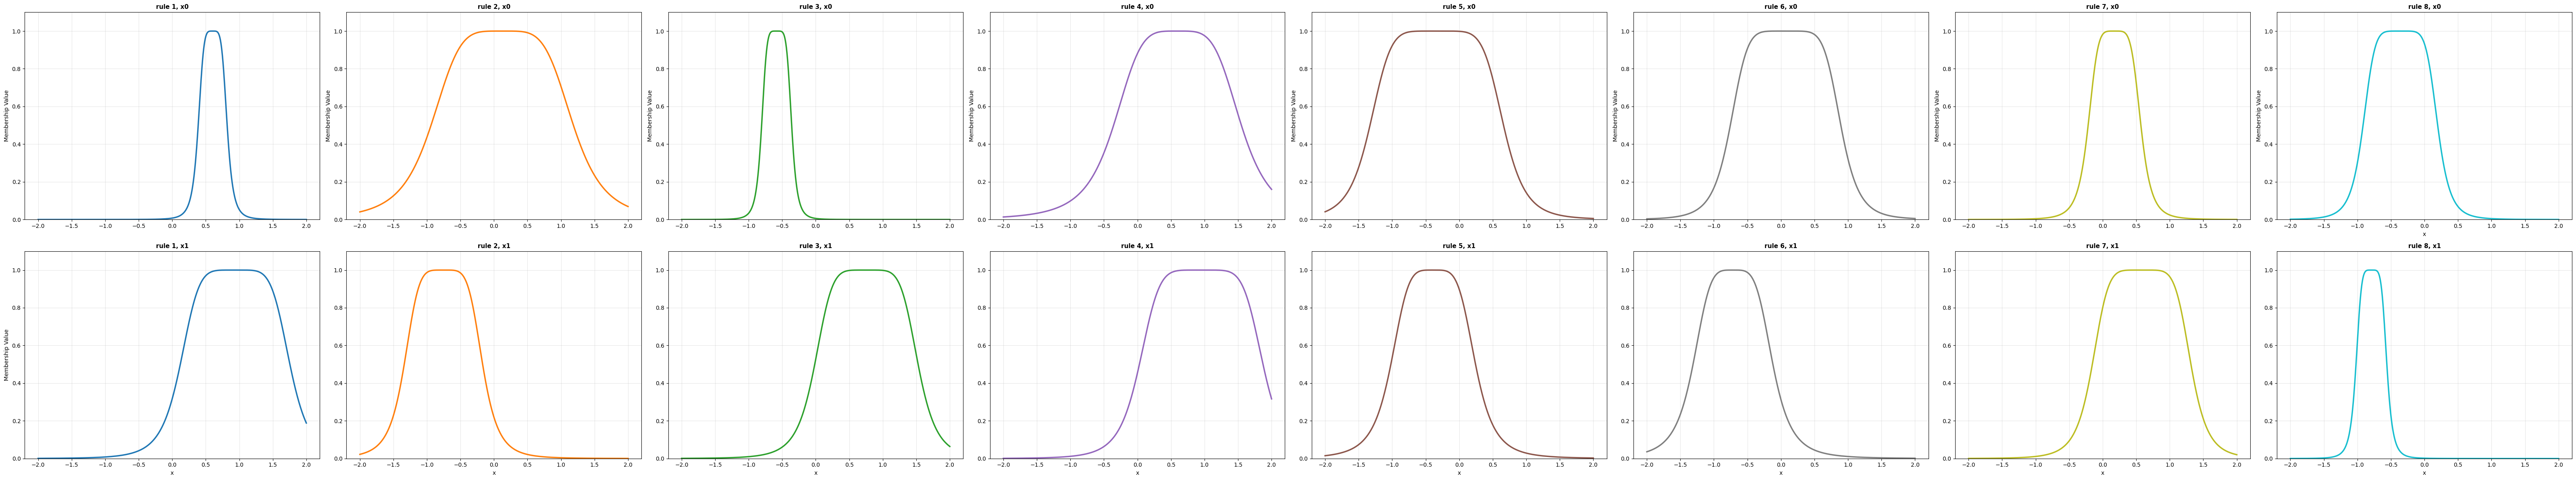

In [5]:
model.plot_premises()

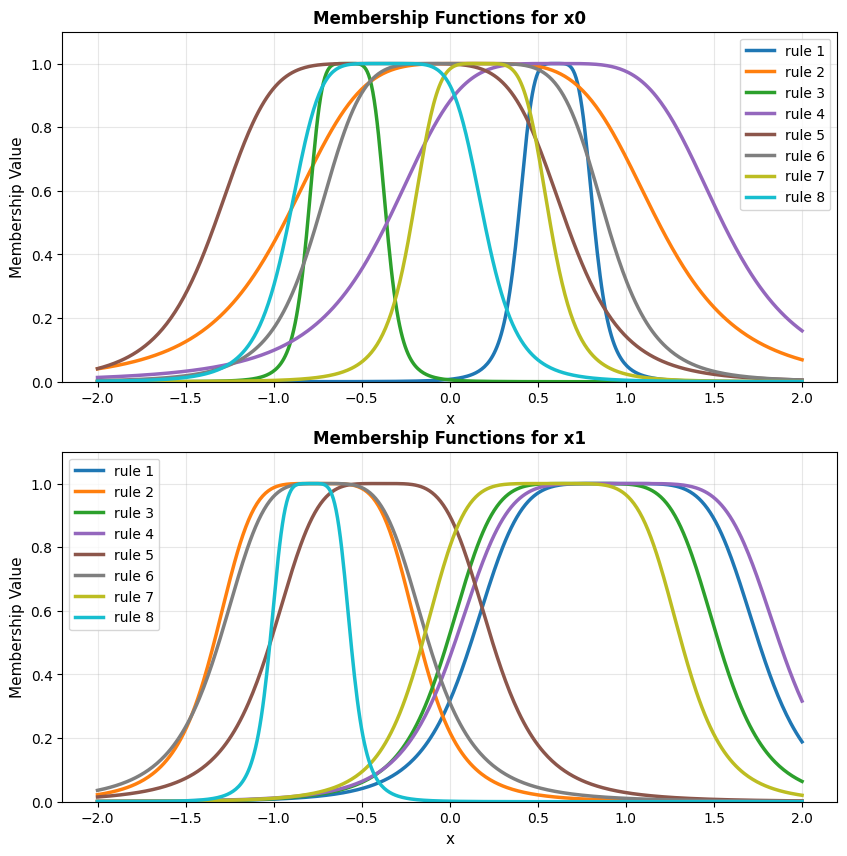

In [6]:
model.plot_premises(group_by_dim=True)

In [7]:
model.get_premises_structure()

x0                            x1                    
               a         b         c         a         b         c
rule 1  0.216022  2.377197  0.603441  0.817054  2.784845   0.93778
rule 2  1.061957  2.284797  0.123172  0.584521   2.50315   -0.7537
rule 3   0.22403  2.699497 -0.582692  0.770716  2.805639  0.756263
rule 4  0.952921  2.142406  0.596906  0.921553  2.964463  0.950537
rule 5  0.995907   3.06279 -0.334654  0.631249  2.236458 -0.387935
rule 6  0.824062  3.073164   0.06878  0.595377  2.143188 -0.715717
rule 7  0.393371  2.506439  0.176078   0.73524  2.948051   0.58049
rule 8  0.556503  2.996696 -0.359312  0.230052  2.608811 -0.790881

In [8]:
model.get_premises()

tensor([[[ 0.2160,  2.3772,  0.6034],
         [ 1.0620,  2.2848,  0.1232],
         [ 0.2240,  2.6995, -0.5827],
         [ 0.9529,  2.1424,  0.5969],
         [ 0.9959,  3.0628, -0.3347],
         [ 0.8241,  3.0732,  0.0688],
         [ 0.3934,  2.5064,  0.1761],
         [ 0.5565,  2.9967, -0.3593]],

        [[ 0.8171,  2.7848,  0.9378],
         [ 0.5845,  2.5031, -0.7537],
         [ 0.7707,  2.8056,  0.7563],
         [ 0.9216,  2.9645,  0.9505],
         [ 0.6312,  2.2365, -0.3879],
         [ 0.5954,  2.1432, -0.7157],
         [ 0.7352,  2.9481,  0.5805],
         [ 0.2301,  2.6088, -0.7909]]])

In [9]:
model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,-0.481213,0.780747,0.418581
rule 2,0.097081,-0.444359,-0.796560
rule 3,0.711067,-0.917218,-0.158026
rule 4,-0.930336,-0.784902,-0.859340
rule 5,-0.310318,0.539191,0.116808
rule 6,-0.235396,-0.660786,0.415862
rule 7,0.175548,0.813653,0.427022
rule 8,-0.824525,-0.493926,0.405877


In [10]:
model.init_consequents(x_train, y_train)

In [11]:
model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,0.478606,1.858071,-1.061435
rule 2,0.333293,-2.947656,-0.465030
rule 3,-0.411709,-0.239483,0.133637
rule 4,-0.512045,0.170687,0.680186
rule 5,1.544875,-0.007962,1.781425
rule 6,-1.228040,3.128463,0.755892
rule 7,0.606450,1.614432,-1.117765
rule 8,0.296312,-1.638930,-0.853417


In [12]:
model.get_rules_structure()

premises                                                    \
              x0                            x1                       
               a         b         c         a         b         c   
rule 1  0.216022  2.377197  0.603441  0.817054  2.784845   0.93778   
rule 2  1.061957  2.284797  0.123172  0.584521   2.50315   -0.7537   
rule 3   0.22403  2.699497 -0.582692  0.770716  2.805639  0.756263   
rule 4  0.952921  2.142406  0.596906  0.921553  2.964463  0.950537   
rule 5  0.995907   3.06279 -0.334654  0.631249  2.236458 -0.387935   
rule 6  0.824062  3.073164   0.06878  0.595377  2.143188 -0.715717   
rule 7  0.393371  2.506439  0.176078   0.73524  2.948051   0.58049   
rule 8  0.556503  2.996696 -0.359312  0.230052  2.608811 -0.790881   

       output 1 consequents                      
                         x0        x1            
                         c0        c1        c2  
rule 1             0.478606  1.858071 -1.061435  
rule 2             0.333293 -2.947656 -0.465030  
rule 3            -0.411709 -0.239483  0.133637  
rule 4            -0.512045  0.170687  0.680186  
rule 5             1.544875 -0.007962  1.781425  
rule 6            -1.228040  3.128463  0.755892  
rule 7             0.606450  1.614432 -1.117765  
rule 8             0.296312 -1.638930 -0.853417

In [13]:
model(x_train[:10])

tensor([0.4950, 0.5665, 0.5502, 0.4903, 0.4652, 0.5098, 0.4907, 0.6215, 0.5575,
        0.5752], grad_fn=<SqueezeBackward1>)

In [14]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([0.4950, 0.5665, 0.5502, 0.4903, 0.4652, 0.5098, 0.4907, 0.6215, 0.5575,
        0.5752])


In [15]:
model.predict(x_train[:10])

tensor([0.4950, 0.5665, 0.5502, 0.4903, 0.4652, 0.5098, 0.4907, 0.6215, 0.5575,
        0.5752])

## Binary output

In [16]:
x_train = 2 * torch.rand(200, 3) - 1

In [17]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([1, 1, 0, 0, 1, 0, 0, 1, 0, 1])

In [18]:
bin_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=10, # 10 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='sigmoid', # Tipo de salida: capa sigmoide
)

In [19]:
bin_model.predict(x_train[:10])

tensor([1, 0, 1, 1, 1, 1, 0, 1, 0, 1])

In [20]:
bin_model(x_train[:10])

tensor([0.5086, 0.4927, 0.7763, 0.6075, 0.5383, 0.5974, 0.4780, 0.7217, 0.4076,
        0.5247], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [21]:
x_train = 2 * torch.rand(200, 3) - 1

In [22]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([2, 2, 1, 0, 3, 0, 2, 2, 0, 3])

In [25]:
mul_class_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=15, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [26]:
mul_class_model.predict(x_train[:10])

tensor([2, 2, 2, 0, 2, 2, 2, 2, 2, 2])

In [27]:
mul_class_model(x_train[:10])

tensor([[ 0.5849, -0.3616,  0.8483,  0.2446],
        [ 0.1688,  0.1959,  0.6525, -0.0632],
        [-0.0511, -0.1008,  0.2569,  0.0958],
        [ 0.4866, -0.0017, -0.0736,  0.0556],
        [-0.1575, -0.2371,  0.3385,  0.1035],
        [-0.0448, -0.3466,  0.4691,  0.1405],
        [ 0.1478, -0.2792,  0.3647,  0.2960],
        [ 0.3791, -0.3517,  0.8697,  0.2024],
        [-0.0251, -0.2754,  0.3341,  0.2431],
        [ 0.2265, -0.1858,  0.3864,  0.3083]], grad_fn=<SqueezeBackward1>)

In [28]:
mul_class_model(x_train[:10], return_probs=True)

tensor([[0.2940, 0.1141, 0.3826, 0.2092],
        [0.2251, 0.2313, 0.3651, 0.1785],
        [0.2237, 0.2128, 0.3044, 0.2591],
        [0.3528, 0.2165, 0.2015, 0.2293],
        [0.2056, 0.1899, 0.3376, 0.2669],
        [0.2167, 0.1602, 0.3623, 0.2608],
        [0.2466, 0.1609, 0.3064, 0.2860],
        [0.2530, 0.1218, 0.4132, 0.2120],
        [0.2213, 0.1723, 0.3170, 0.2894],
        [0.2551, 0.1689, 0.2993, 0.2768]], grad_fn=<SoftmaxBackward0>)

In [29]:
print(mul_class_model.get_rules_structure().to_string())

         premises                                                   output 1 consequents                               output 2 consequents                               output 3 consequents                               output 4 consequents                              
               x0                  x1                  x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2          
               mu     sigma        mu     sigma        mu     sigma                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3
rule 1  -0.349642  0.923992  0.410204  0.563455 -0.228981  0.313632            -0.480592  0.614719  0.363004  0.839113            -0.840257 -0.723155  0.315928  0.844931             0.

## Multiple outputs

In [30]:
x_train = 2 * torch.rand(200, 2) - 1

In [32]:
model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=9, # 9 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

In [33]:
model.get_consequents_structure()

[              x0        x1          
               c0        c1        c2
 rule 1  0.340826 -0.221882 -0.929264
 rule 2  0.021950  0.168677 -0.591631
 rule 3 -0.553617 -0.394511  0.870354
 rule 4  0.152064  0.346833 -0.913318
 rule 5  0.100854  0.360251 -0.579802
 rule 6 -0.597897  0.098767 -0.881693
 rule 7 -0.006245 -0.928548 -0.243764
 rule 8  0.691362  0.799860  0.146463
 rule 9  0.416610 -0.590253 -0.671398,
               x0        x1          
               c0        c1        c2
 rule 1  0.303039  0.931129  0.919489
 rule 2 -0.354485  0.006067 -0.685577
 rule 3 -0.400135 -0.438368  0.821194
 rule 4 -0.363463 -0.009309 -0.369073
 rule 5 -0.538177 -0.399168 -0.200141
 rule 6  0.560247 -0.738819 -0.921610
 rule 7 -0.339218 -0.377528  0.966941
 rule 8 -0.847828  0.651131 -0.730110
 rule 9 -0.854864  0.858099 -0.097880]

In [34]:
model(x_train[:10])

tensor([[-0.7126, -0.6963],
        [-0.6944, -0.4496],
        [-0.4905,  0.2725],
        [-0.7401,  0.2434],
        [-0.2186, -0.8088],
        [-0.5842, -0.4007],
        [-0.6819,  0.2005],
        [-0.6832, -0.2485],
        [-0.9856,  0.1374],
        [-0.5055,  0.3024]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [36]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=6, # 6 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [37]:
model(x_train[:10])

tensor([[-0.2491, -0.3715,  0.5146],
        [-0.3723,  0.6572,  0.4641],
        [-0.6741,  0.4004,  0.6140],
        [-0.0523,  0.4969,  0.5135],
        [-0.3897,  0.3167,  0.4314],
        [-0.2054, -0.1150,  0.3886],
        [-0.3971,  0.7328,  0.4802],
        [-0.1364, -0.5329,  0.5919],
        [-0.0576,  0.0018,  0.4850],
        [-0.4132,  0.7847,  0.4768]], grad_fn=<SqueezeBackward1>)

In [38]:
model(x_train[:10], return_probs=True)

tensor([[0.2481, 0.2195, 0.5324],
        [0.1637, 0.4584, 0.3779],
        [0.1324, 0.3876, 0.4800],
        [0.2226, 0.3855, 0.3919],
        [0.1887, 0.3824, 0.4289],
        [0.2560, 0.2802, 0.4637],
        [0.1539, 0.4762, 0.3699],
        [0.2671, 0.1797, 0.5533],
        [0.2644, 0.2806, 0.4549],
        [0.1482, 0.4910, 0.3608]], grad_fn=<SoftmaxBackward0>)

In [39]:
model.predict(x_train[:10])

tensor([2, 1, 2, 2, 2, 2, 1, 2, 2, 1])